In [4]:
print("cell testing...")

cell testing...


In [5]:
# Step-1: Prepare a classification dataset (Tumor = 1, No Tumor = 0)
import os, random, shutil

# Input directories (original images + masks)
IMG_DIR = "/kaggle/input/litsdataset2/images"
MASK_DIR = "/kaggle/input/litsdataset2/masks"

# Output directory (new classification folder structure)
OUT_DIR = "/kaggle/working/class_dataset"

# Step-2: Create folders for train/val and labels (0 = no tumor, 1 = tumor)
for split in ["train", "val"]:
    for cls in ["0", "1"]:
        os.makedirs(f"{OUT_DIR}/{split}/{cls}", exist_ok=True)

# Step-3: Load all image file names and shuffle them
images = [f for f in os.listdir(IMG_DIR) if f.endswith(".png")]
random.shuffle(images)

# Step-4: 80-20 split
split_idx = int(len(images) * 0.8)
train_files = images[:split_idx]
val_files   = images[split_idx:]

# Step-5: Simple tumor check using mask file size
def is_tumor(mask_path):
    return os.path.getsize(mask_path) > 1200

# Step-6: Process and copy images into class folders
def process(files, split):
    for i, f in enumerate(files):
        img_path = os.path.join(IMG_DIR, f)
        mask_path = os.path.join(MASK_DIR, f)
        
        label = "1" if is_tumor(mask_path) else "0"
        dst = os.path.join(OUT_DIR, split, label, f)
        shutil.copyfile(img_path, dst)
        
        if i % 5000 == 0:
            print(split, i, "/", len(files))

# Step-7: Run processing
print("Processing train...")
process(train_files, "train")

print("Processing val...")
process(val_files, "val")

print("✅ Dataset preparation DONE!")

Processing train...
train 0 / 46910
train 5000 / 46910
train 10000 / 46910
train 15000 / 46910
train 20000 / 46910
train 25000 / 46910
train 30000 / 46910
train 35000 / 46910
train 40000 / 46910
train 45000 / 46910
Processing val...
val 0 / 11728
val 5000 / 11728
val 10000 / 11728
✅ Dataset preparation DONE!


In [6]:
import os

base = "/kaggle/working/class_dataset"

print("="*50)
print("📂 Dataset Structure Verification")
print("="*50)

for split in ["train", "val"]:
    for cls in ["0", "1"]:
        path = f"{base}/{split}/{cls}"
        if os.path.exists(path):
            count = len(os.listdir(path))
            print(f"{path} => {count} files")
        else:
            print(f"❌ {path} => NOT FOUND!")
print("="*50)

📂 Dataset Structure Verification
/kaggle/working/class_dataset/train/0 => 37334 files
/kaggle/working/class_dataset/train/1 => 9576 files
/kaggle/working/class_dataset/val/0 => 9336 files
/kaggle/working/class_dataset/val/1 => 2392 files


In [7]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from torch.cuda.amp import GradScaler, autocast
import timm
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report, 
    roc_curve, auc, precision_recall_fscore_support,
    accuracy_score, roc_auc_score
)
from sklearn.preprocessing import label_binarize
import warnings
warnings.filterwarnings('ignore')

# ---------------------------
# Dataset path
# ---------------------------
DATA_DIR = "/kaggle/working/class_dataset"
TRAIN_DIR = os.path.join(DATA_DIR, "train")
VAL_DIR   = os.path.join(DATA_DIR, "val")

# ---------------------------
# Image transforms
# ---------------------------
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 4

train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.485,0.456,0.406),(0.229,0.224,0.225)),
])

val_transforms = transforms.Compose([
    transforms.Resize(int(IMG_SIZE*1.1)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize((0.485,0.456,0.406),(0.229,0.224,0.225)),
])

# ---------------------------
# Datasets & DataLoaders
# ---------------------------
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)
val_dataset   = datasets.ImageFolder(VAL_DIR, transform=val_transforms)

NUM_CLASSES = len(train_dataset.classes)
class_names = train_dataset.classes

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print("="*60)
print("📊 Dataset Information")
print("="*60)
print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")
print(f"Classes: {class_names}")
print(f"Number of classes: {NUM_CLASSES}")
print("="*60)

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

📊 Dataset Information
Train samples: 46910
Val samples: 11728
Classes: ['0', '1']
Number of classes: 2


In [8]:
# ---------------------------
# Device setup
# ---------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"\n🖥️  Using device: {DEVICE}")

# ---------------------------
# ConvNeXt model setup
# ---------------------------
model = timm.create_model("convnext_tiny", pretrained=True, num_classes=NUM_CLASSES)
model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)

scaler = GradScaler()

print("✅ ConvNeXt-Tiny model loaded successfully!")
print(f"📌 Total parameters: {sum(p.numel() for p in model.parameters()):,}")


🖥️  Using device: cuda


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

✅ ConvNeXt-Tiny model loaded successfully!
📌 Total parameters: 27,821,666


In [9]:
# ---------------------------
# Training function
# ---------------------------
def train_one_epoch(model, loader, criterion, optimizer, scaler, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    progress_bar = tqdm(loader, desc="Training", leave=False)
    
    for images, labels in progress_bar:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        with autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
        progress_bar.set_postfix(loss=loss.item())
    
    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    
    # Calculate precision, recall, F1
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='weighted', zero_division=0
    )
    
    return epoch_loss, epoch_acc, precision, recall, f1


# ---------------------------
# Validation function
# ---------------------------
def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    all_probs = []
    
    progress_bar = tqdm(loader, desc="Validation", leave=False)
    
    with torch.no_grad():
        for images, labels in progress_bar:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            
            progress_bar.set_postfix(loss=loss.item())
    
    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    
    # Calculate precision, recall, F1
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='weighted', zero_division=0
    )
    
    return epoch_loss, epoch_acc, precision, recall, f1, all_preds, all_labels, all_probs

print("✅ Training and validation functions defined!")

✅ Training and validation functions defined!


In [10]:
# ---------------------------
# Training configuration
# ---------------------------
NUM_EPOCHS = 50
best_val_acc = 0.0
best_epoch = 0

# History tracking
history = {
    'train_loss': [], 'train_acc': [], 'train_precision': [], 'train_recall': [], 'train_f1': [],
    'val_loss': [], 'val_acc': [], 'val_precision': [], 'val_recall': [], 'val_f1': []
}

# To store best model predictions for final evaluation
best_preds = None
best_labels = None
best_probs = None

print("\n" + "="*60)
print("🚀 Starting Training...")
print("="*60)

# ---------------------------
# Training loop
# ---------------------------
for epoch in range(NUM_EPOCHS):
    print(f"\n📍 Epoch {epoch+1}/{NUM_EPOCHS}")
    print("-" * 60)
    
    # Train
    train_loss, train_acc, train_prec, train_rec, train_f1 = train_one_epoch(
        model, train_loader, criterion, optimizer, scaler, DEVICE
    )
    
    # Validate
    val_loss, val_acc, val_prec, val_rec, val_f1, val_preds, val_labels, val_probs = validate(
        model, val_loader, criterion, DEVICE
    )
    
    # Update learning rate
    scheduler.step()
    
    # Save metrics
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_precision'].append(train_prec)
    history['train_recall'].append(train_rec)
    history['train_f1'].append(train_f1)
    
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_precision'].append(val_prec)
    history['val_recall'].append(val_rec)
    history['val_f1'].append(val_f1)
    
    # Print epoch results
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Train Prec: {train_prec:.4f} | Train Rec: {train_rec:.4f} | Train F1: {train_f1:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f} | Val Prec:   {val_prec:.4f} | Val Rec:   {val_rec:.4f} | Val F1:   {val_f1:.4f}")
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1
        best_preds = val_preds
        best_labels = val_labels
        best_probs = val_probs
        torch.save(model.state_dict(), 'best_convnext_model.pth')
        print(f"✅ Best model saved! (Epoch {best_epoch}, Val Acc: {best_val_acc:.4f})")

print("\n" + "="*60)
print("🎉 Training Complete!")
print("="*60)
print(f"🏆 Best Epoch: {best_epoch}")
print(f"🏆 Best Validation Accuracy: {best_val_acc:.4f}")


🚀 Starting Training...

📍 Epoch 1/50
------------------------------------------------------------


Train Loss: 0.1167 | Train Acc: 0.9535 | Train Prec: 0.9531 | Train Rec: 0.9535 | Train F1: 0.9532
Val Loss:   0.0415 | Val Acc:   0.9844 | Val Prec:   0.9843 | Val Rec:   0.9844 | Val F1:   0.9843
✅ Best model saved! (Epoch 1, Val Acc: 0.9844)

📍 Epoch 2/50
------------------------------------------------------------


Train Loss: 0.0782 | Train Acc: 0.9683 | Train Prec: 0.9682 | Train Rec: 0.9683 | Train F1: 0.9682
Val Loss:   0.0312 | Val Acc:   0.9870 | Val Prec:   0.9872 | Val Rec:   0.9870 | Val F1:   0.9870
✅ Best model saved! (Epoch 2, Val Acc: 0.9870)

📍 Epoch 3/50
------------------------------------------------------------


Train Loss: 0.0686 | Train Acc: 0.9721 | Train Prec: 0.9719 | Train Rec: 0.9721 | Train F1: 0.9720
Val Loss:   0.0307 | Val Acc:   0.9888 | Val Prec:   0.9888 | Val Rec:   0.9888 | Val F1:   0.9888
✅ Best model saved! (Epoch 3, Val Acc: 0.9888)

📍 Epoch 4/50
------------------------------------------------------------


Train Loss: 0.0622 | Train Acc: 0.9754 | Train Prec: 0.9753 | Train Rec: 0.9754 | Train F1: 0.9753
Val Loss:   0.0356 | Val Acc:   0.9860 | Val Prec:   0.9865 | Val Rec:   0.9860 | Val F1:   0.9861

📍 Epoch 5/50
------------------------------------------------------------


...

Train Loss: 0.0213 | Train Acc: 0.9915 | Train Prec: 0.9915 | Train Rec: 0.9915 | Train F1: 0.9915
Val Loss:   0.0172 | Val Acc:   0.9934 | Val Prec:   0.9934 | Val Rec:   0.9934 | Val F1:   0.9934

📍 Epoch 47/50
------------------------------------------------------------


Train Loss: 0.0227 | Train Acc: 0.9913 | Train Prec: 0.9913 | Train Rec: 0.9913 | Train F1: 0.9913
Val Loss:   0.0226 | Val Acc:   0.9929 | Val Prec:   0.9929 | Val Rec:   0.9929 | Val F1:   0.9929

📍 Epoch 48/50
------------------------------------------------------------


Train Loss: 0.0245 | Train Acc: 0.9910 | Train Prec: 0.9910 | Train Rec: 0.9910 | Train F1: 0.9910
Val Loss:   0.0166 | Val Acc:   0.9938 | Val Prec:   0.9938 | Val Rec:   0.9938 | Val F1:   0.9938

📍 Epoch 49/50
------------------------------------------------------------


Train Loss: 0.0242 | Train Acc: 0.9908 | Train Prec: 0.9908 | Train Rec: 0.9908 | Train F1: 0.9908
Val Loss:   0.0195 | Val Acc:   0.9933 | Val Prec:   0.9933 | Val Rec:   0.9933 | Val F1:   0.9933

📍 Epoch 50/50
------------------------------------------------------------


Train Loss: 0.0277 | Train Acc: 0.9896 | Train Prec: 0.9896 | Train Rec: 0.9896 | Train F1: 0.9896
Val Loss:   0.0199 | Val Acc:   0.9919 | Val Prec:   0.9919 | Val Rec:   0.9919 | Val F1:   0.9919

🎉 Training Complete!
🏆 Best Epoch: 28
🏆 Best Validation Accuracy: 0.9947


In [16]:
# ---------------------------
# Only Simple Performance Table
# ---------------------------
print("\n" + "="*80)
print(f"Final Model Performance Summary (Epoch {best_epoch})")
print("="*80)

best_idx = best_epoch - 1

# Calculate metrics
val_acc = history['val_acc'][best_idx]
val_prec = history['val_precision'][best_idx]
val_rec = history['val_recall'][best_idx]
val_f1 = history['val_f1'][best_idx]

# Print simple table
print(f"\n{'Metric':<25} {'Value':<20} {'Percentage':<15}")
print("-" * 60)
print(f"{'Accuracy':<25} {val_acc:<20.4f} {val_acc*100:<14.2f}%")
print(f"{'Precision':<25} {val_prec:<20.4f} {val_prec*100:<14.2f}%")
print(f"{'Recall (Sensitivity)':<25} {val_rec:<20.4f} {val_rec*100:<14.2f}%")
print(f"{'F1-Score':<25} {val_f1:<20.4f} {val_f1*100:<14.2f}%")
print("="*80)


Final Model Performance Summary (Epoch 28)

Metric                    Value                Percentage     
------------------------------------------------------------
Accuracy                  0.9947               99.47         %
Precision                 0.9947               99.47         %
Recall (Sensitivity)      0.9947               99.47         %
F1-Score                  0.9947               99.47         %


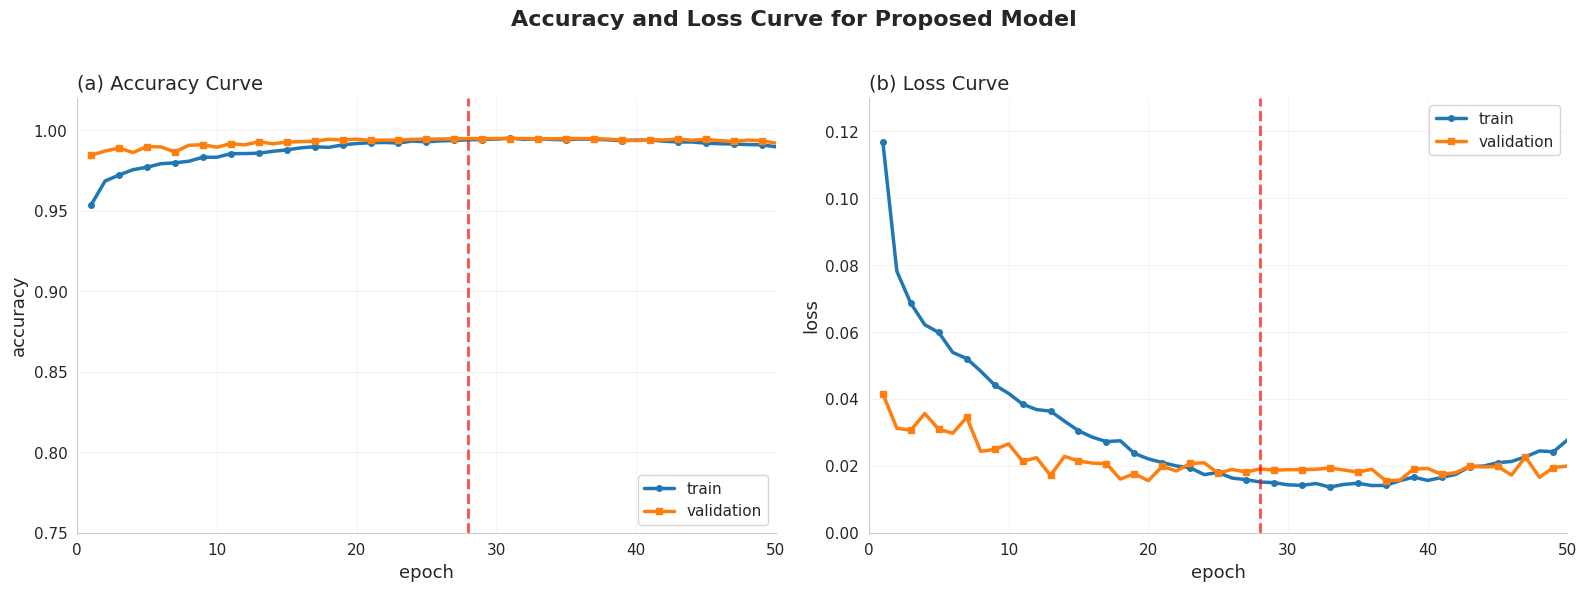

✅ Professional Accuracy and Loss curves saved as 'accuracy_loss_curves.png'


In [17]:
# ---------------------------
# Plot Accuracy and Loss curves (Professional Style)
# ---------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 11

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Define colors
train_color = '#1f77b4'  # Blue
val_color = '#ff7f0e'    # Orange

# ============================================
# (a) Accuracy Curve
# ============================================
axes[0].plot(range(1, NUM_EPOCHS+1), history['train_acc'], 
             label='train', color=train_color, linewidth=2.5, marker='o', 
             markersize=4, markevery=2)

axes[0].plot(range(1, NUM_EPOCHS+1), history['val_acc'], 
             label='validation', color=val_color, linewidth=2.5, marker='s', 
             markersize=4, markevery=2)

# Best epoch vertical line
axes[0].axvline(x=best_epoch, color='red', linestyle='--', linewidth=2, alpha=0.7)

# Styling
axes[0].set_xlabel('epoch', fontsize=13, fontweight='normal')
axes[0].set_ylabel('accuracy', fontsize=13, fontweight='normal')
axes[0].set_title('(a) Accuracy Curve', fontsize=14, fontweight='normal', loc='left')
axes[0].legend(loc='lower right', fontsize=11, frameon=True, shadow=False)
axes[0].grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
axes[0].set_xlim(0, NUM_EPOCHS)
axes[0].set_ylim(0.75, 1.02)  # Adjust based on your data range
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# ============================================
# (b) Loss Curve
# ============================================
axes[1].plot(range(1, NUM_EPOCHS+1), history['train_loss'], 
             label='train', color=train_color, linewidth=2.5, marker='o', 
             markersize=4, markevery=2)

axes[1].plot(range(1, NUM_EPOCHS+1), history['val_loss'], 
             label='validation', color=val_color, linewidth=2.5, marker='s', 
             markersize=4, markevery=2)

# Best epoch vertical line
axes[1].axvline(x=best_epoch, color='red', linestyle='--', linewidth=2, alpha=0.7)

# Styling
axes[1].set_xlabel('epoch', fontsize=13, fontweight='normal')
axes[1].set_ylabel('loss', fontsize=13, fontweight='normal')
axes[1].set_title('(b) Loss Curve', fontsize=14, fontweight='normal', loc='left')
axes[1].legend(loc='upper right', fontsize=11, frameon=True, shadow=False)
axes[1].grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
axes[1].set_xlim(0, NUM_EPOCHS)
axes[1].set_ylim(0, 0.13)  # Adjust based on your data range
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# Main title
fig.suptitle('Accuracy and Loss Curve for Proposed Model', 
             fontsize=16, fontweight='bold', y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('accuracy_loss_curves.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("✅ Professional Accuracy and Loss curves saved as 'accuracy_loss_curves.png'")

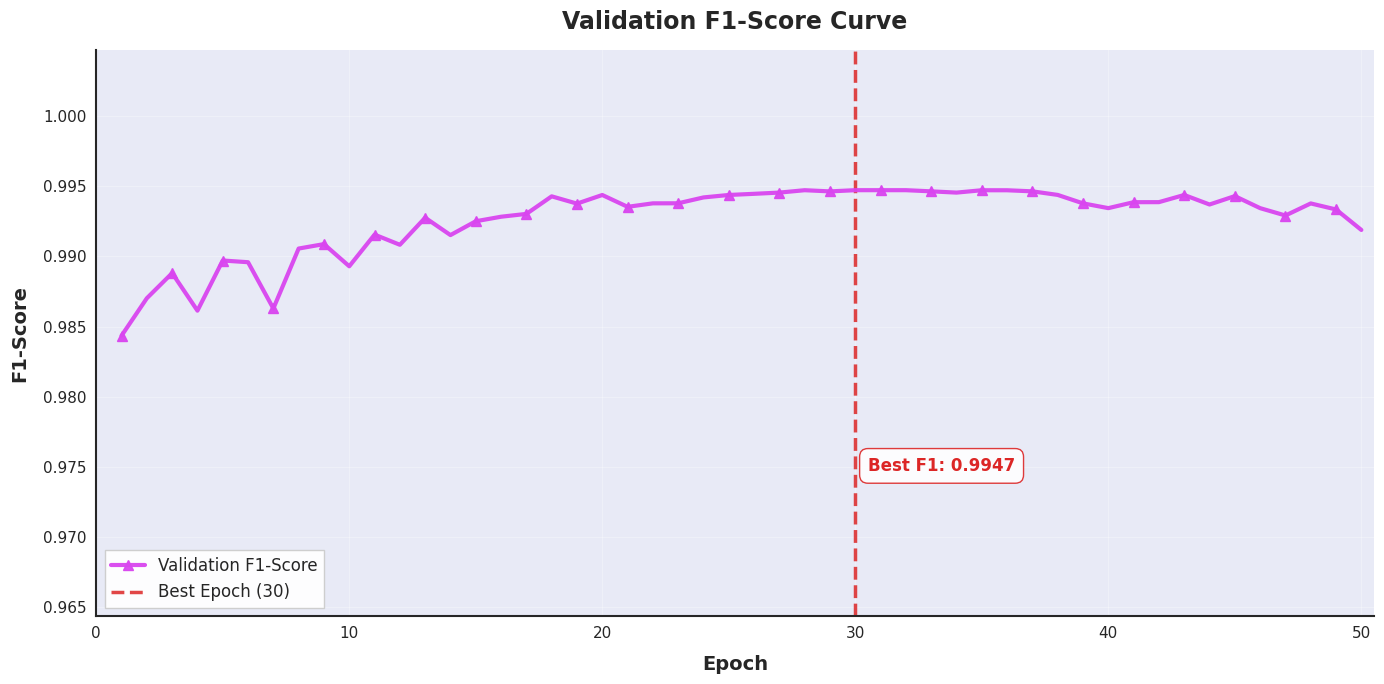

✅ Validation F1-Score curve saved as 'validation_f1_score_curve.png'
🏆 Best F1-Score: 0.9947 at Epoch 30


In [18]:
# ---------------------------
# Plot Validation F1-Score curve (Professional Style)
# ---------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("white")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 12

# Create figure
fig, ax = plt.subplots(figsize=(14, 7))

# Background color
bg_color = '#E8EAF6'  # Light purple-grey
ax.set_facecolor(bg_color)
fig.patch.set_facecolor('white')

# Find best F1-score and its epoch
best_f1_score = max(history['val_f1'])
best_f1_epoch = history['val_f1'].index(best_f1_score) + 1

# Plot Validation F1-Score
line_color = '#D946EF'  # Magenta/Pink color
ax.plot(range(1, NUM_EPOCHS+1), history['val_f1'], 
        label='Validation F1-Score', 
        color=line_color, 
        linewidth=3.0, 
        marker='^',  # Triangle marker
        markersize=7, 
        markevery=2,
        alpha=0.95,
        zorder=2)

# Best epoch vertical line
ax.axvline(x=best_f1_epoch, color='#DC2626', linestyle='--', 
           linewidth=2.5, alpha=0.85, zorder=1,
           label=f'Best Epoch ({best_f1_epoch})')

# Add text annotation for best F1-score
ax.text(best_f1_epoch + 0.5, best_f1_score - 0.02, 
        f'Best F1: {best_f1_score:.4f}',
        fontsize=12, 
        color='#DC2626', 
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', 
                  edgecolor='#DC2626', alpha=0.9))

# Styling
ax.set_xlabel('Epoch', fontsize=14, fontweight='bold', labelpad=10)
ax.set_ylabel('F1-Score', fontsize=14, fontweight='bold', labelpad=10)
ax.set_title('Validation F1-Score Curve', fontsize=17, fontweight='bold', pad=15)

# Legend
ax.legend(loc='lower left', fontsize=12, frameon=True, 
          fancybox=False, shadow=False, framealpha=0.95)

# Grid
ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.9, color='white')

# Axis limits
ax.set_xlim(0, NUM_EPOCHS + 0.5)

# Dynamic y-axis based on F1-score range
f1_min = min(history['val_f1'])
f1_max = max(history['val_f1'])
f1_range = f1_max - f1_min

if f1_range < 0.1:  # If very high F1-scores (close to 1.0)
    ax.set_ylim(max(0.90, f1_min - 0.02), min(1.01, f1_max + 0.01))
else:
    ax.set_ylim(max(0, f1_min - f1_range * 0.1), 
                min(1.05, f1_max + f1_range * 0.05))

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

# Tick parameters
ax.tick_params(axis='both', which='major', labelsize=11, width=1.5)

plt.tight_layout()
plt.savefig('validation_f1_score_curve.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()

print("✅ Validation F1-Score curve saved as 'validation_f1_score_curve.png'")
print(f"🏆 Best F1-Score: {best_f1_score:.4f} at Epoch {best_f1_epoch}")

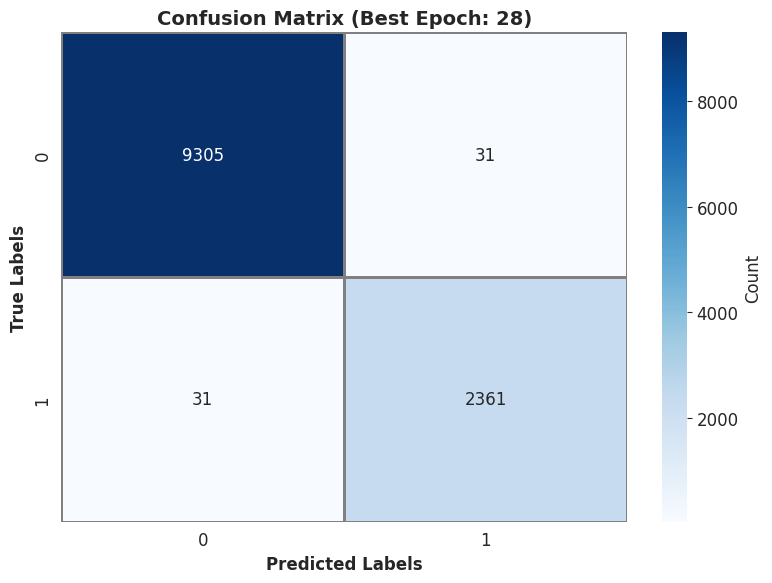

✅ Confusion matrix saved as 'confusion_matrix.png'


In [19]:
# ---------------------------
# Confusion Matrix
# ---------------------------
cm = confusion_matrix(best_labels, best_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'}, linewidths=1, linecolor='gray')
plt.xlabel('Predicted Labels', fontsize=12, fontweight='bold')
plt.ylabel('True Labels', fontsize=12, fontweight='bold')
plt.title(f'Confusion Matrix (Best Epoch: {best_epoch})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Confusion matrix saved as 'confusion_matrix.png'")

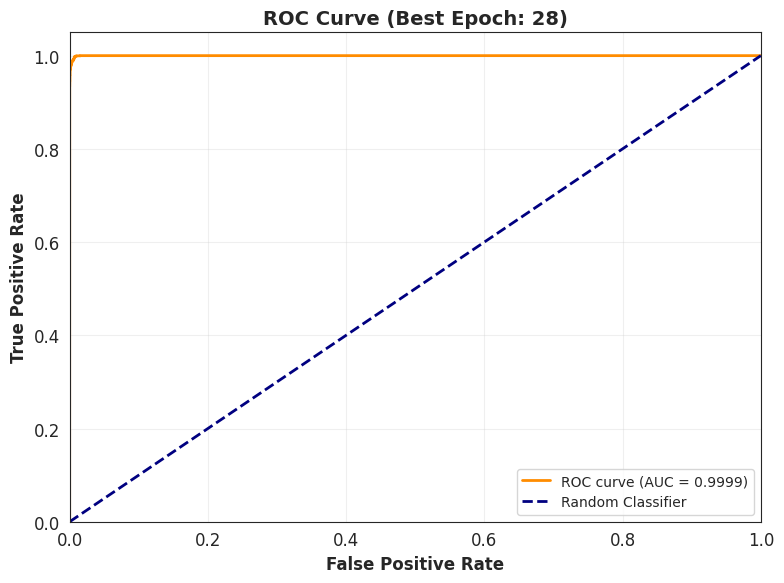

✅ ROC curve saved as 'roc_curve.png' (AUC: 0.9999)


In [20]:
# ---------------------------
# ROC Curve
# ---------------------------
best_probs_array = np.array(best_probs)
best_labels_array = np.array(best_labels)

# For binary classification
if NUM_CLASSES == 2:
    fpr, tpr, _ = roc_curve(best_labels_array, best_probs_array[:, 1])
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
    plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
    plt.title(f'ROC Curve (Best Epoch: {best_epoch})', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('roc_curve.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✅ ROC curve saved as 'roc_curve.png' (AUC: {roc_auc:.4f})")

# For multi-class classification
else:
    best_labels_bin = label_binarize(best_labels_array, classes=range(NUM_CLASSES))
    
    plt.figure(figsize=(10, 8))
    
    for i in range(NUM_CLASSES):
        fpr, tpr, _ = roc_curve(best_labels_bin[:, i], best_probs_array[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'Class {class_names[i]} (AUC = {roc_auc:.4f})')
    
    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
    plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
    plt.title(f'ROC Curves - Multi-Class (Best Epoch: {best_epoch})', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", fontsize=9)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('roc_curve_multiclass.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Multi-class ROC curves saved as 'roc_curve_multiclass.png'")